In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
import os
import sys
%matplotlib inline

In [2]:
sys.path.append(os.path.expanduser('/home/thappe/HeaT'))
print(os.getcwd())
from HeaT.preprocessing import multiyear_multiday_running_percentile

/gpfs/home4/thappe/HeaT/Notebooks


In [3]:
sys.path.append(os.path.expanduser('/home/thappe/gdbscan'))
print(os.getcwd())
from gdbscan_ERA5_weighted_v2 import *

/gpfs/home4/thappe/HeaT/Notebooks


In [4]:
data_path = "/home/thappe/data/"

## load in heatwaves from csv files

In [5]:
name_path_dict

{'t2m': ('/1940-2023_T2M_westEU_June23-JA-Sept7_LENTISGRID.nc',
  '/T2M_westEU_LENTIS_1940-2023_90thp_15d.nc'),
 'T2M_dynamic': ('/T2M_decomposition/T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc',
  '/T2M_decomposition/90th_percentile/T2M_dynamic_westEU_LENTIS_1940-2023.nc'),
 'T2M_minus_thermo': ('/T2M_decomposition/T2M_minus_thermo_westEU_LENTIS_1940-2023.nc',
  '/T2M_decomposition/90th_percentile/T2M_minus_thermo_westEU_LENTIS_1940-2023.nc')}

In [13]:
t2m_data = xr.open_dataset(f"{data_path}{name_path_dict['t2m'][0]}")["t2m"].astype("float16")
t2m_dynamic_data = xr.open_dataset(f"{data_path}{name_path_dict['T2M_dynamic'][0]}")["T2M_dynamic"].astype("float16")
t2m_minus_thermo_data = xr.open_dataset(f"{data_path}{name_path_dict['T2M_minus_thermo'][0]}")["T2M_minus_thermo"].astype("float16")


In [79]:
np.unique(t2m_dynamic_data.time.dt.year).shape

(84,)

#### Heatwaves selected on IVM BAZIS cluster with cdo running percentiles

In [6]:
ls /home/thappe/data/heatwaves

ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
ERA5_2020_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
ERA5_2020_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
ERA5_land_sea_mask_WestEU_lentisgrid.nc
gdbscan_on_snellius/
gridarea_westEU_lentisgrid.nc
T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc


In [7]:
T2M = pd.read_csv(
    f"{data_path}/heatwaves/ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv")
T2M_dyn_heatwaves = pd.read_csv(
    f"{data_path}/heatwaves/T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv")
T2M_minus_thermo_heatwaves = pd.read_csv(
    f"{data_path}/heatwaves/T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv")


In [23]:
T2M

,year,Heatwave number (clusterID),day 0 (index),start date,end date,duration in days,maximum spatial extent in km2,cumulative_heat_index (C*km2),peak intensity (max(sum(temp) per day)),peak intensity day,average daily temp (mean(mean C per day)),average daily temp (mean of all temperatures),"spatial range (lon_min, lon_max, lat_min, lat_max)",midpoint tracker
0,1940,-1 (NOISE),,,,,,,,,,,,
1,1940,0,32,1940-08-02,1940-08-01,5,10143,783385.94,401.08,1940-08-03,17.98,18.03,"(-9.84375, -5.625, 51.5788101317764, 54.385812...","(-8.0859375, 53.33318703966727)(-7.734375, 53...."
2,1940,1,33,1940-08-03,1940-08-05,3,7215,382667.35,302.26,1940-08-04,21.75,21.79,"(-4.21875, 0.0, 47.3683028045918, 48.771805603...","(-2.8125, 48.070054217623465)(-2.4609375, 48.0..."
3,1940,2,48,1940-08-18,1940-08-17,4,13840,982597.18,585.27,1940-08-17,23.56,23.71,"(-9.140625, -6.328125, 40.3507847105177, 43.15...","(-7.734375, 41.75428874036156)(-8.4375, 41.754..."
4,1940,3,47,1940-08-17,1940-08-22,6,6751,940448.53,319.06,1940-08-18,28.77,28.81,"(-7.03125, -4.921875, 36.1402713807781, 38.245...","(-5.9765625, 37.54377597548913)(-5.9765625, 37..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,2023,4,35,2023-08-05,2023-08-28,24,289096,62363611.65,9651.78,2023-08-21,20.65,18.91,"(-9.84375, 14.765625, 35.4385190210863, 54.385...","(-8.0859375, 38.2455282198601)(-5.9765625, 38...."
942,2023,5,40,2023-08-10,2023-08-12,3,9197,297155.88,293.06,2023-08-10,14.39,14.38,"(-7.03125, -2.8125, 52.2805610111665, 54.38581...","(-4.921875, 53.33318703966727)(-4.5703125, 53...."
943,2023,6,45,2023-08-15,2023-08-19,5,11232,977167.79,432.99,2023-08-16,25.73,25.67,"(0.703125, 4.21875, 35.4385190210863, 36.84202...","(1.40625, 36.140271368586205)(2.4609375, 36.14..."
944,2023,7,47,2023-08-17,2023-08-21,5,6871,415547.57,220.05,2023-08-17,14.88,14.85,"(-7.03125, -2.8125, 52.2805610111665, 54.38581...","(-4.5703125, 53.33318703966727)(-4.921875, 53...."


In [73]:
def heatwave_plot(heatwaves_df, title, offset=False):
    ####
    years = heatwaves_df["year"]
    duration = heatwaves_df['duration in days']
    average_T = heatwaves_df["average daily temp (mean(mean C per day))"]

    spat_ext = heatwaves_df["maximum spatial extent in km2"]

    x, y, z, m = [], [], [], []
    ii = []
    for i in range(len(years)):
        if average_T[i] == " ":
            continue
        x.append(years[i])
        T = float(average_T[i])
        if offset:
            T = T + 273.15
        y.append(T)
        z.append(float(duration[i]))
        m.append(float(spat_ext[i]))

    for i in range(len(x)):
        if float(z[i]) >= 50:
            ii.append(i)
            #print(i, x[i], y[i], z[i], m[i])

    # z = (z - np.max(z)) / np.max(z)
    m = [i / 1000 for i in m] 
    ### 
    
    fig = plt.figure(figsize=(15,10))
    ax = plt.subplot(111)

    sc = ax.scatter(x, y, s=m, c=z, cmap="Reds", alpha=0.7)
    # handles = sc.legend_elements("sizes", num=4)
    # labels = ["0", "1", "2", "3"]

    plt.title(title)
    ax.set_xlabel("years")
    ax.set_ylabel("Average temperature in C")

    # Shrink current axis by 20%
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    # Put a legend to the right of the current axis
    legend1 = ax.legend(*sc.legend_elements("sizes", num=6), loc="center left", title="Max Spatial Extent in 10^4 km2", bbox_to_anchor=(1, 0.75), borderpad=2.5)
    ax.legend(*sc.legend_elements("colors", num=5), loc="center left", title="Duration in days", bbox_to_anchor=(1, 0.25), borderpad=2.5)
    plt.gca().add_artist(legend1)

    plt.show()
    plt.clf()
    plt.hist(z, bins=40)
    plt.xticks([0,1,2,3,4,5,10,15,20,25,30,35])
    plt.title(f"duration in days \n {title}")
    plt.show()
    

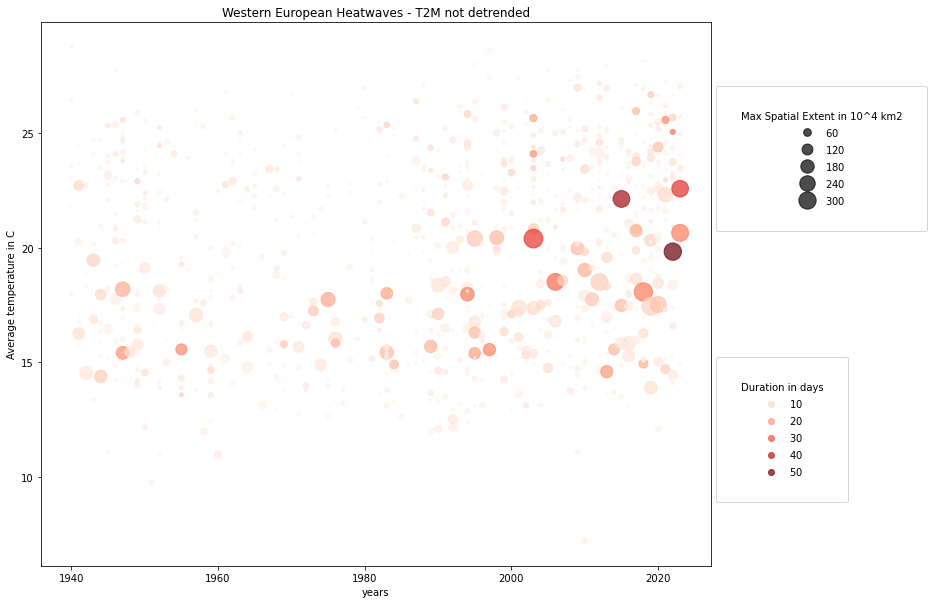

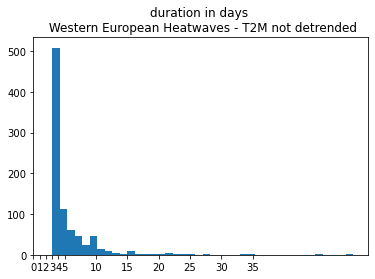

In [74]:
heatwave_plot(T2M, "Western European Heatwaves - T2M not detrended")

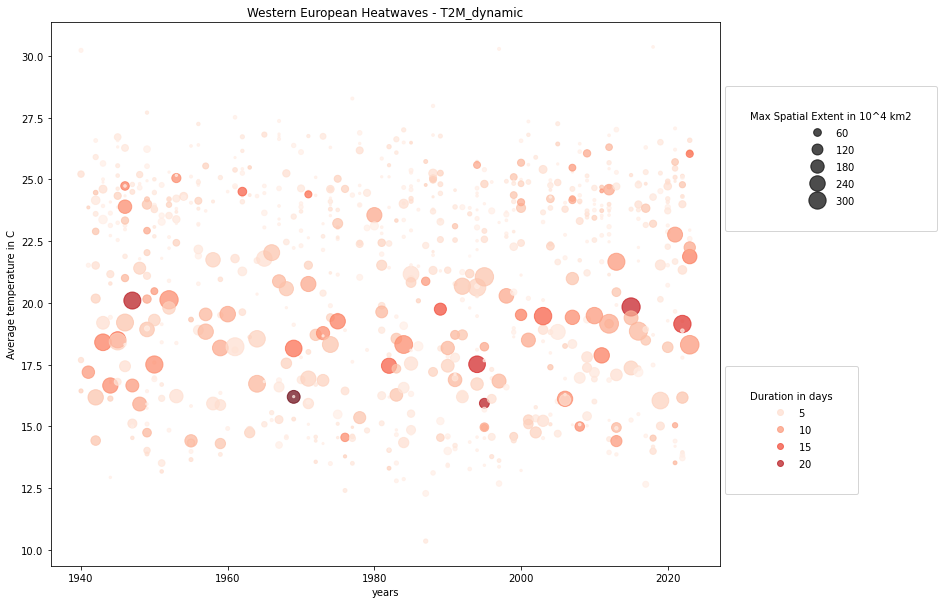

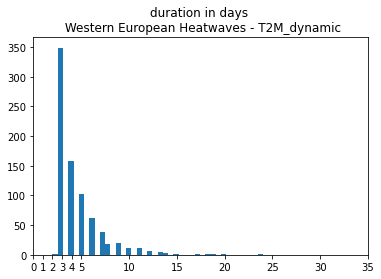

In [75]:
heatwave_plot(T2M_dyn_heatwaves, "Western European Heatwaves - T2M_dynamic", offset=True)

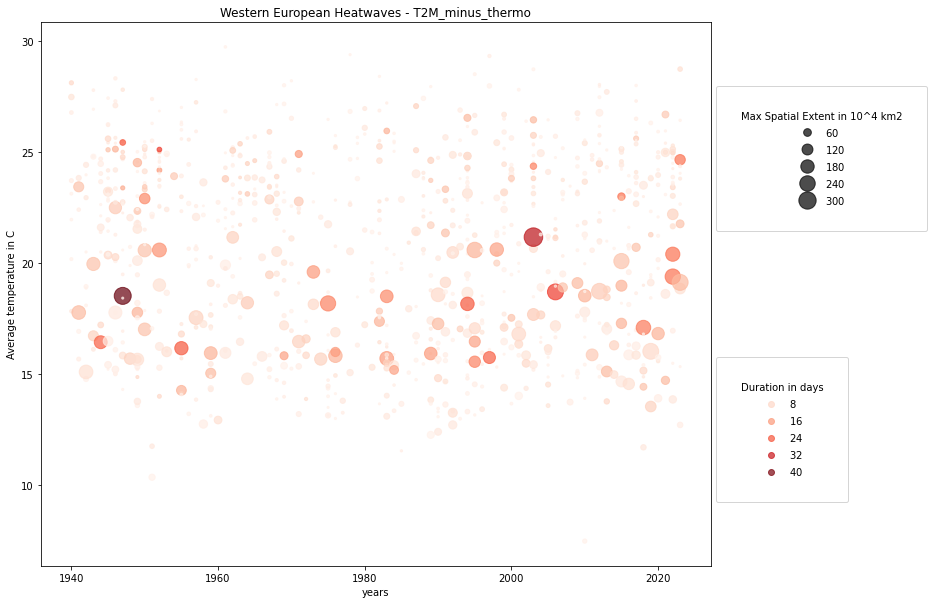

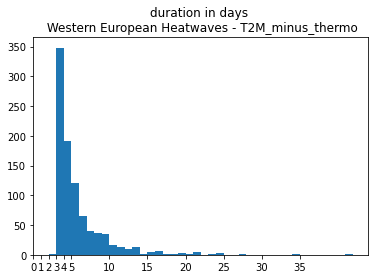

In [76]:
heatwave_plot(T2M_minus_thermo_heatwaves, "Western European Heatwaves - T2M_minus_thermo", offset=True)

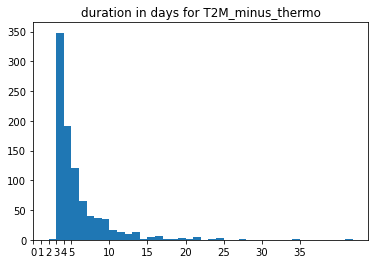

In [68]:
duration_list = []
for duration in T2M_minus_thermo_heatwaves['duration in days']:
    if duration == " ":
            continue
    duration_list.append(float(duration))
    
plt.hist(duration_list, bins=40)
plt.xticks([0,1,2,3,4,5,10,15,20,25,30,35])
plt.title("duration in days for T2M_minus_thermo")
plt.show()